In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
import cv2

# Bài 1:
## 1.1: PHÂN TÍCH CÁC GIÁ TRỊ SUY BIẾN
### Đọc bức ảnh được cung cấp. Đảm bảo ảnh đang ở định dạng grayscale, sau đó chuyển đổi dữ liệu sang kiểu float và chuẩn hóa các giá trị pixel về khoảng [0,1].


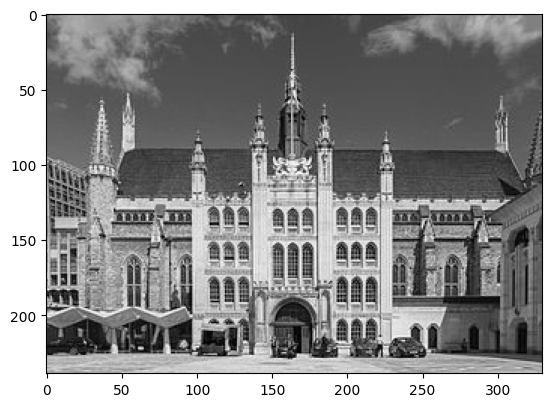

In [46]:
img = cv2.imread(r"D:\PPS\tuan5\de2.jpg")

grayscale = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

grayscale = (grayscale - np.min(grayscale)) / (np.max(grayscale) - np.min(grayscale))

plt.imshow(grayscale, cmap='gray')
plt.show()

### Áp dụng np.linalg.svd lên ma trận ảnh

In [47]:
U, S, Vt = np.linalg.svd(grayscale)
print(U)
print(S)
print(Vt)

[[ 5.96612075e-02 -1.25695706e-01  9.30803432e-03 ... -1.87041044e-03
  -5.10008112e-03 -8.38081050e-02]
 [ 6.00971543e-02 -1.29470083e-01  6.46188400e-03 ...  3.87128208e-03
  -1.28537187e-02  2.09819603e-01]
 [ 6.02741598e-02 -1.31426926e-01  4.32544318e-03 ... -5.26100035e-02
   7.20570087e-02 -2.23517949e-01]
 ...
 [ 9.99470207e-02 -3.53605266e-02  2.09012785e-02 ... -6.85719043e-05
   5.58734002e-03  4.47404711e-03]
 [ 1.00784108e-01 -4.29487167e-02  8.23424091e-03 ... -5.40919106e-03
   1.21955565e-03 -2.83123705e-03]
 [ 1.01806507e-01 -4.85361592e-02  5.69370894e-03 ... -7.88329516e-03
  -1.24710574e-03 -2.02572079e-04]]
[1.32281264e+02 2.10859405e+01 1.69450984e+01 1.30900613e+01
 1.22235123e+01 1.10806054e+01 9.38501817e+00 8.87593219e+00
 8.08491660e+00 7.66988505e+00 6.80847836e+00 6.26371429e+00
 6.25104044e+00 5.66893047e+00 5.35158369e+00 4.95516591e+00
 4.80337098e+00 4.54802528e+00 4.39871966e+00 4.38514038e+00
 4.16615796e+00 3.95849918e+00 3.90375433e+00 3.88198235e+0

### Vẽ đồ thị (line plot hoặc scatter plot) thể hiện 15 giá trị suy biến σ đầu tiên (từ lớn nhất đến nhỏ nhất) để quan sát tốc độ giảm của các giá trị này

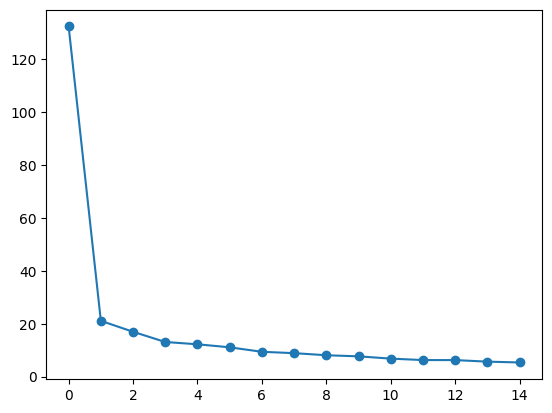

In [48]:
plt.plot(S[:15], marker = 'o')
plt.show()

## 1.2: THỰC NGHIỆM NÉN ẢNH
### Thực hiện tái tạo lại ảnh (compressed image) từ k giá trị suy biến lớn nhất. Hãy chọn 3 mức k khác nhau để thấy rõ sự khác biệt (cụ thể: k = 15,k = 45,k = 90).

In [49]:
def reconstruct_matrix(U, S, Vt, k):
    Sigma = np.diag(S[:k])
    U = U[:, :k]
    Vt = Vt[:k, :]
    return U @ Sigma @ Vt

In [50]:
image_k15 = reconstruct_matrix(U, S, Vt, 15)
image_k45 = reconstruct_matrix(U, S, Vt, 45)
image_k90 = reconstruct_matrix(U, S, Vt, 90)

### Hiển thị trên cùng một hình 4 bức ảnh (sử dụng matplotlib): Ảnh gốc và 3 Ảnh đã nén tương ứng với từng mức k. Gắn tiêu đề (title) rõ ràng.

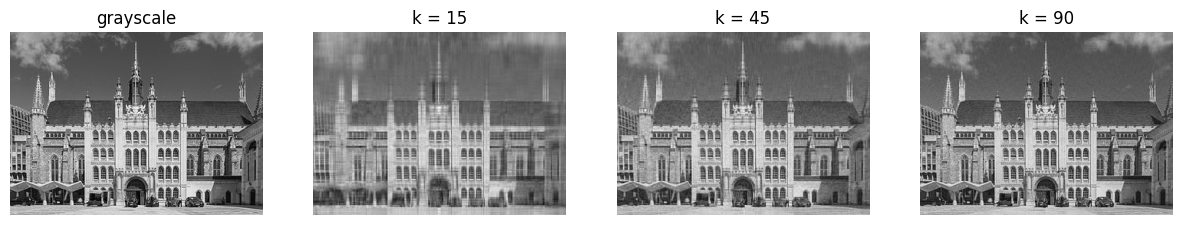

In [51]:
plt.figure(figsize=(15, 12))
plt.subplot(1, 4, 1)
plt.axis('off')
plt.imshow(grayscale, cmap='gray')
plt.title('grayscale')

plt.subplot(1, 4, 2)
plt.axis('off')
plt.imshow(image_k15, cmap='gray')
plt.title('k = 15')

plt.subplot(1, 4, 3)
plt.axis('off')
plt.imshow(image_k45, cmap='gray')
plt.title('k = 45')

plt.subplot(1, 4, 4)
plt.axis('off')
plt.imshow(image_k90, cmap='gray')
plt.title('k = 90')
plt.show()

## 1.3:  ĐÁNH GIÁ HIỆU NĂNG NÉN
### Storage Ratio

In [52]:
Storage_Ratio_k15 = 15 * (U.shape[0] + Vt.shape[0] + 1) / (U.shape[0] * Vt.shape[1])
Storage_Ratio_k45 = 45 * (U.shape[0] + Vt.shape[0] + 1) / (U.shape[0] * Vt.shape[1])
Storage_Ratio_k90 = 90 * (U.shape[0] + Vt.shape[0] + 1) / (U.shape[0] * Vt.shape[1])

### Viết hàm tính sai số Mean Squared Error (MSE) giữa hai bức ảnh

In [53]:
def MSE(img1, img2):
    return np.mean((img1 - img2) ** 2)

###  In ra màn hình kết quả tính toán MSE và Tỷ lệ lưu trữ cho từng mức k = 15,45,90. Rút ra nhận xét ngắn gọn về sự đánh đổi giữa chất lượng ảnh và dung lượng lưu trữ.


In [54]:
print("k = 15:")
print("Storage_Ratio:",Storage_Ratio_k15,"%")
print("MSE between it and original:", MSE(image_k15, grayscale))

print("k = 45:")
print("Storage_Ratio:",Storage_Ratio_k45,"%")
print("MSE between it and original:", MSE(image_k45, grayscale))

print("k = 90:")
print("Storage_Ratio:",Storage_Ratio_k90,"%")
print("MSE between it and original:", MSE(image_k90, grayscale))

k = 15:
Storage_Ratio: 0.10840623811335108 %
MSE between it and original: 0.0068693012188674124
k = 45:
Storage_Ratio: 0.3252187143400532 %
MSE between it and original: 0.0024212089276437485
k = 90:
Storage_Ratio: 0.6504374286801065 %
MSE between it and original: 0.0007066866452807098


Nhận xét: K càng lớn thì tỉ lệ lưu trữ càng lớn và MSE của nó và ảnh grayscale ban đầu càng nhỏ. Hay nói cách khác là càng giữ được nhiều chi tiết của ảnh thì dung lượng càng lớn.

# GRADIENT DESCENT

### 

## 2.1: DỮ LIỆU GIẢ LẬP

In [55]:
np.random.seed(1)
X = np.random.uniform(0, 12, 400)
eps = np.random.normal(0, 1, 400)
y = np.zeros(400)
for i in range(400):
    if X[i] + eps[i] >= 6:
        y[i] = 1
    else:
        y[i] = 0

## 2.2: HÀM LOSS VÀ GRADIENT
### Hàm Loss trung bình trên toàn bộ N mẫu dữ liệu là Binary Cross-Entropy (BCE):

In [56]:
def Loss(y, y_hat):
    loss = np.sum(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    return loss

### Cài đặt hàm tính gradient của BCE theo w và b

In [57]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict(x, w, b):
    z = w * x + b
    return sigmoid(z)

def GD(x, y, w, b):
    y_pred = predict(x, w, b)
    dw = (y_pred - y) * x
    db = (y_pred - y)
    return dw, db

## 2.3: HUẤN LUYỆN VÀ SO SÁNH
### Stochastic GD & Mini-batch SGD

In [58]:
w = 0
b = 0
learning_rate = 0.005
epochs = 100
batch_size = 128

In [59]:
# Stochastic GD
Loss_Stochastic = []
for epoch in range(epochs):
    indices = np.random.permutation(400)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    epoch_loss = 0
    for i in range(len(X)):
        dw, db = GD(X_shuffled[i], y_shuffled[i], w, b)
        w -= learning_rate * dw
        b -= learning_rate * db
        y_hat = predict(X_shuffled[i], w, b)
        epoch_loss += Loss(np.array([y_shuffled[i]]), np.array([y_hat]))
    
    epoch_loss /= -400
    Loss_Stochastic.append(epoch_loss)

In [60]:
print(w, b)

1.0395674239385957 -6.1834049559202855


In [61]:
np.random.seed(1)
w = 0
b = 0
learning_rate = 0.005
epochs = 100
batch_size = 128

In [62]:
# Mini-batch GD
Loss_mini_batch = []
for epoch in range(epochs):
    indices = np.random.permutation(400)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    epoch_loss = 0
    for i in range(0, 400, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        for j in range(len(X_batch)):
            dw, db = GD(X_batch[j], y_batch[j], w, b)
            w -= learning_rate * (dw / len(X_batch))
            b -= learning_rate * (db / len(X_batch))
        y_pred_batch = predict(X_batch, w, b)
        epoch_loss += Loss(y_batch, y_pred_batch)

    epoch_loss /= -400
    Loss_mini_batch.append(epoch_loss)

In [63]:
print(w, b)

0.19056481556186086 -0.31286461167439


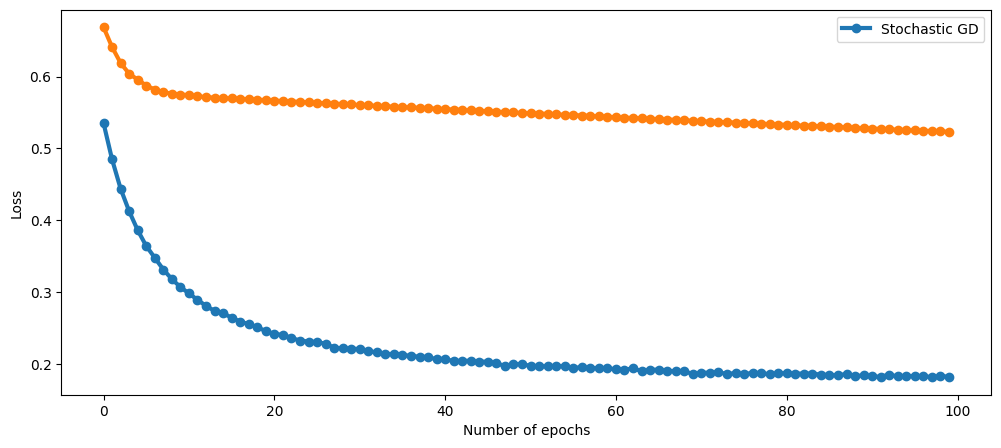

In [64]:
plt.figure(figsize=(12, 5))

plt.plot(Loss_Stochastic, linewidth=3, marker='o')
plt.xlabel('Number of epochs')
plt.ylabel('Loss')
plt.legend(['Stochastic GD'])

plt.plot(Loss_mini_batch, linewidth=3, marker='o')
plt.xlabel('Number of epochs')  
plt.ylabel('Loss')

plt.show()